# Windowed zref and density contrast optimization
The tutorials on [density contrast optimization](../tutorial/05_density_optimization.ipynb) and [reference level optimization](../tutorial/06_reference_level_optimization.ipynb) show how to use constraint points (locations of known topography) to find a single optimal density contrast and reference level (`zref`) for the entire inversion region. However, in many real-world scenarios these properties vary spatially; for example, the density contrast between sediment and basement may change regionally, or the appropriate reference level may differ from one side of the region to the other.

For these situations, the method `optimize_inversion_zref_density_contrast_windowed` provides a windowed optimization scheme:

1) the region is tiled with square windows of a set width, optionally overlapping,
2) within each window, a standard optimization is run using the gravity data, model, and constraint points which fall inside the window (padded by an optional buffer to reduce edge effects), giving each window its own optimal parameter value(s),
3) the per-window optimal values, located at the window centers, are merged (interpolated) into continuous grids of spatially variable zref and / or density contrast values,
4) a final inversion is run over the full region using these spatially variable grids.

This notebook demonstrates the windowed scheme for a density contrast optimization and a zref optimization.

## Import packages

In [1]:
# set EPSG for plotting functions
import os

import polartoolkit as ptk
import verde as vd
import xarray as xr

import invert4geom

os.environ["POLARTOOLKIT_EPSG"] = "3857"

## Create the synthetic model
As in the other examples, we create a synthetic `true` topography which we hope to recover with the inversions, and a set of randomly located constraint points where we assume the true topography is known (i.e. from seismic surveys or drill sites).

mean of true topography: 492.3 m


/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:1820: FutureWarning: The 'barwidth' parameter has been deprecated since v0.18.0 and will be removed in v0.20.0. Please use 'bar_width' instead.
  self.histogram(


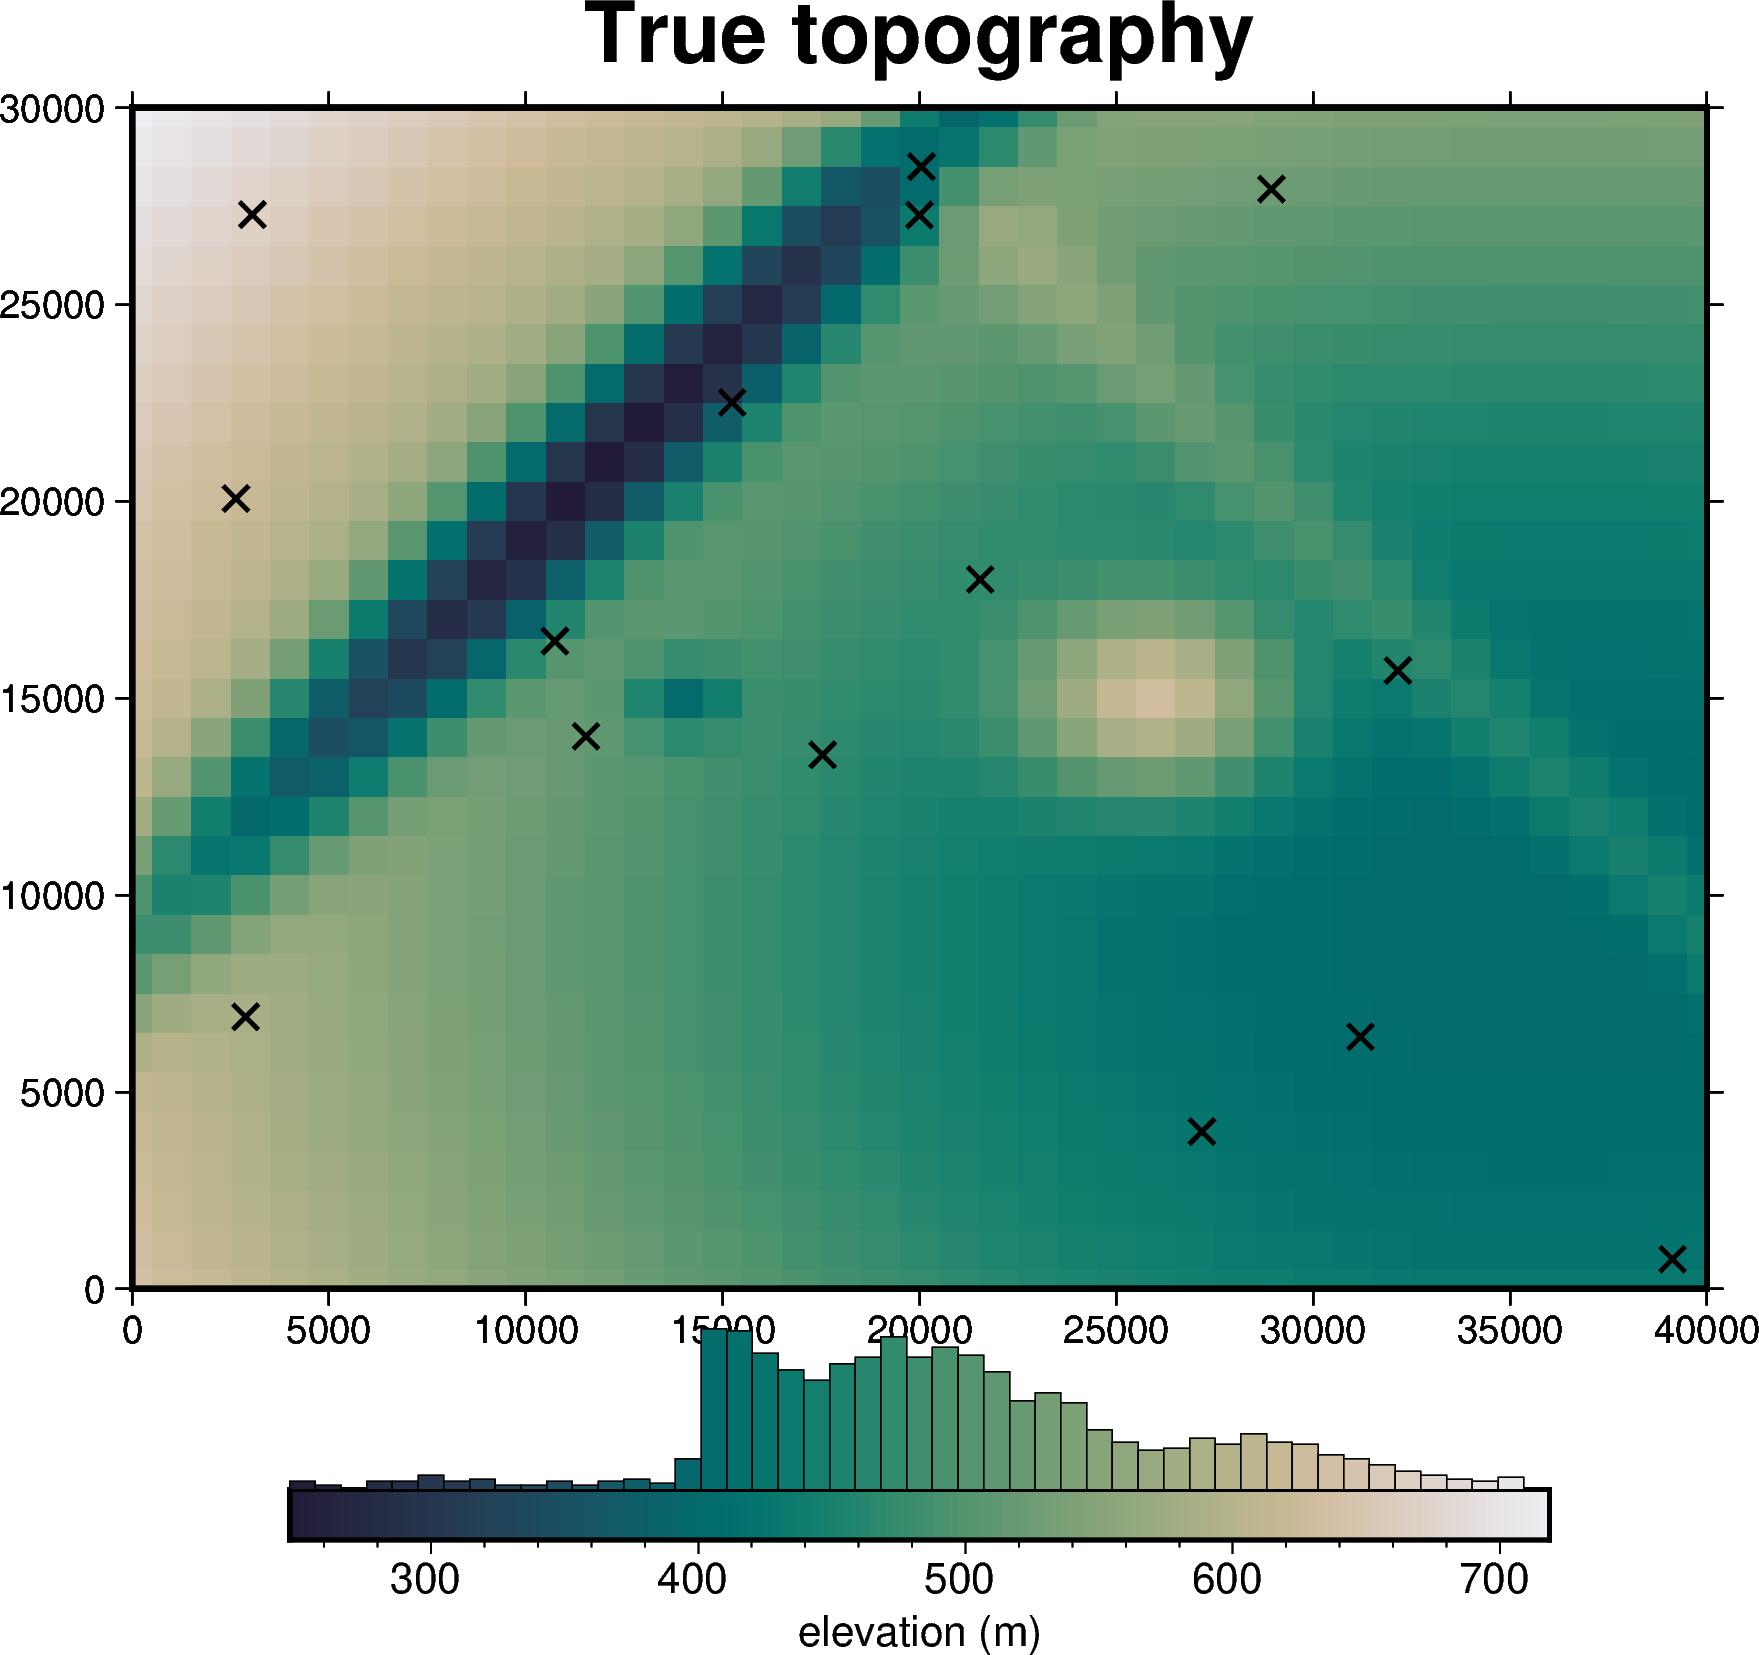

In [2]:
spacing = 1000
region = (0, 40000, 0, 30000)

true_topography, _, constraint_points, _ = invert4geom.load_synthetic_model(
    spacing=spacing,
    region=region,
    number_of_constraints=15,
    density_contrast=2669,
    plot_topography_diff=False,
    plot_gravity=False,
)

true_zref = true_topography.values.mean()
print(f"mean of true topography: {true_zref:.1f} m")

fig = ptk.plot_grid(
    true_topography,
    fig_height=10,
    title="True topography",
    cmap="rain",
    reverse_cpt=True,
    hist=True,
    cbar_label="elevation (m)",
    points=constraint_points,
    points_style="x.3c",
    frame=["nSWe", "xaf10000", "yaf10000"],
)
fig.show()

Since we will create the observed gravity and set up the starting inversion several times (once per scenario), we define two small helper functions. The first forward models the gravity of a `true` model and contaminates it with noise, and the second creates a flat starting model, calculates the gravity misfit and its regional / residual components, and sets up the inversion.

In [3]:
def make_observed_gravity(topography, density_contrast, zref):
    """forward gravity of the true model, with 0.2 mGal of random noise"""
    true_model = invert4geom.create_model(
        zref=zref,
        density_contrast=density_contrast,
        topography=topography.to_dataset(name="upward"),
    )
    coords = vd.grid_coordinates(
        region=region,
        spacing=spacing,
        extra_coords=1000,  # survey elevation
    )
    observations = vd.make_xarray_grid(
        (coords[0], coords[1]),
        data=coords[2],
        data_names="upward",
        dims=("northing", "easting"),
    )
    data = invert4geom.create_data(observations)
    data.inv.forward_gravity(true_model, "grav")
    data["gravity_anomaly"], _ = invert4geom.contaminate(
        data.grav,
        stddev=0.2,
        percent=False,
        seed=0,
    )
    return data

## Density contrast optimization
First we look at the case where the reference level is known, but the density contrast varies spatially. We create a `true` density distribution with two zones; a lower density (~1800 kg/m$^3$, e.g. sediment) and a higher density (~3000 kg/m$^3$, e.g. crystalline basement), as in the [variable density notebook](variable_density_contrast.ipynb).

First we will perform a standard (non-windowed) density contrast optimization, then will perform a windowed version to recover a spatially-variable density contrast.

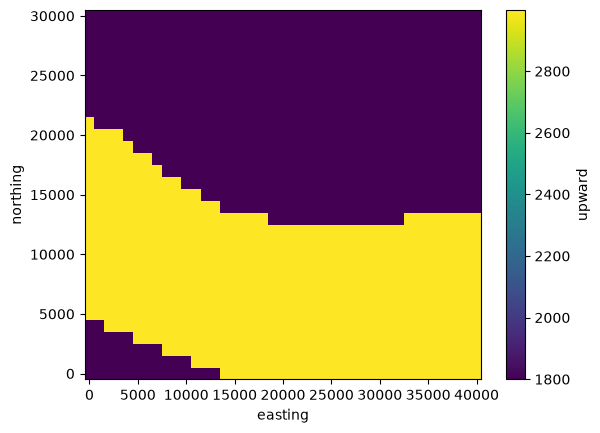

In [4]:
# use some synthetic data to create a two-zone density distribution
synthetic_data = invert4geom.synthetic_topography_regional(
    spacing,
    region,
    yoffset=20,
)
density_dist = xr.where(synthetic_data > 0, 1800, 3000)

# density contrast relative to air (~1 kg/m3)
true_density_contrast = density_dist - 1

true_density_contrast.plot()

In [5]:
# create the observed gravity of the true topography with the variable density
data = make_observed_gravity(true_topography, true_density_contrast, true_zref)

# create the starting model with a constant density guess and the known zref
# in this simple scenario we assume there is no regional field
starting_topography = invert4geom.create_topography(
    method="flat",
    upward=true_zref,
    region=region,
    spacing=spacing,
)
starting_model = invert4geom.create_model(
    zref=true_zref,
    density_contrast=2400,
    topography=starting_topography,
)
data.inv.forward_gravity(starting_model)
data.inv.regional_separation(method="constant", constant=0)

inv = invert4geom.Inversion(
    data,
    starting_model,
    solver_damping=0.1,
    max_iterations=30,
    l2_norm_tolerance=0.45,  # gravity error is 0.2 mGal
    delta_l2_norm_tolerance=1.005,
)

### Normal density contrast optimization

  0%|          | 0/4 [00:00<?, ?it/s]

Inversion terminated due to max_iterations limit. Consider increasing this limit.


  0%|          | 0/4 [00:00<?, ?it/s]

'forward_gravity' already a variable of `grav_ds`, but is being overwritten since calculate_starting_gravity is True
'reg' already a column of `grav_df`, but is being overwritten since calculate_regional_misfit is True


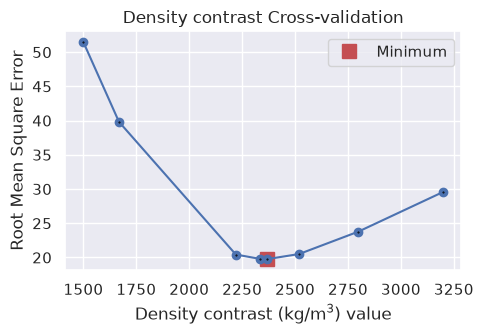

In [6]:
density_optimization_obj = inv.optimize_inversion_zref_density_contrast(
    n_trials=8,
    constraints_df=constraint_points,
    density_contrast_limits=(1500, 3200),
    regional_grav_kwargs={"method": "constant", "constant": 0},
    starting_topography_kwargs={"method": "flat"},
    fname="../tmp/single_density_optimization",
    progressbar=True,
)

In [7]:
inv.used_density_contrast

2368

/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:1820: FutureWarning: The 'barwidth' parameter has been deprecated since v0.18.0 and will be removed in v0.20.0. Please use 'bar_width' instead.
  self.histogram(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13

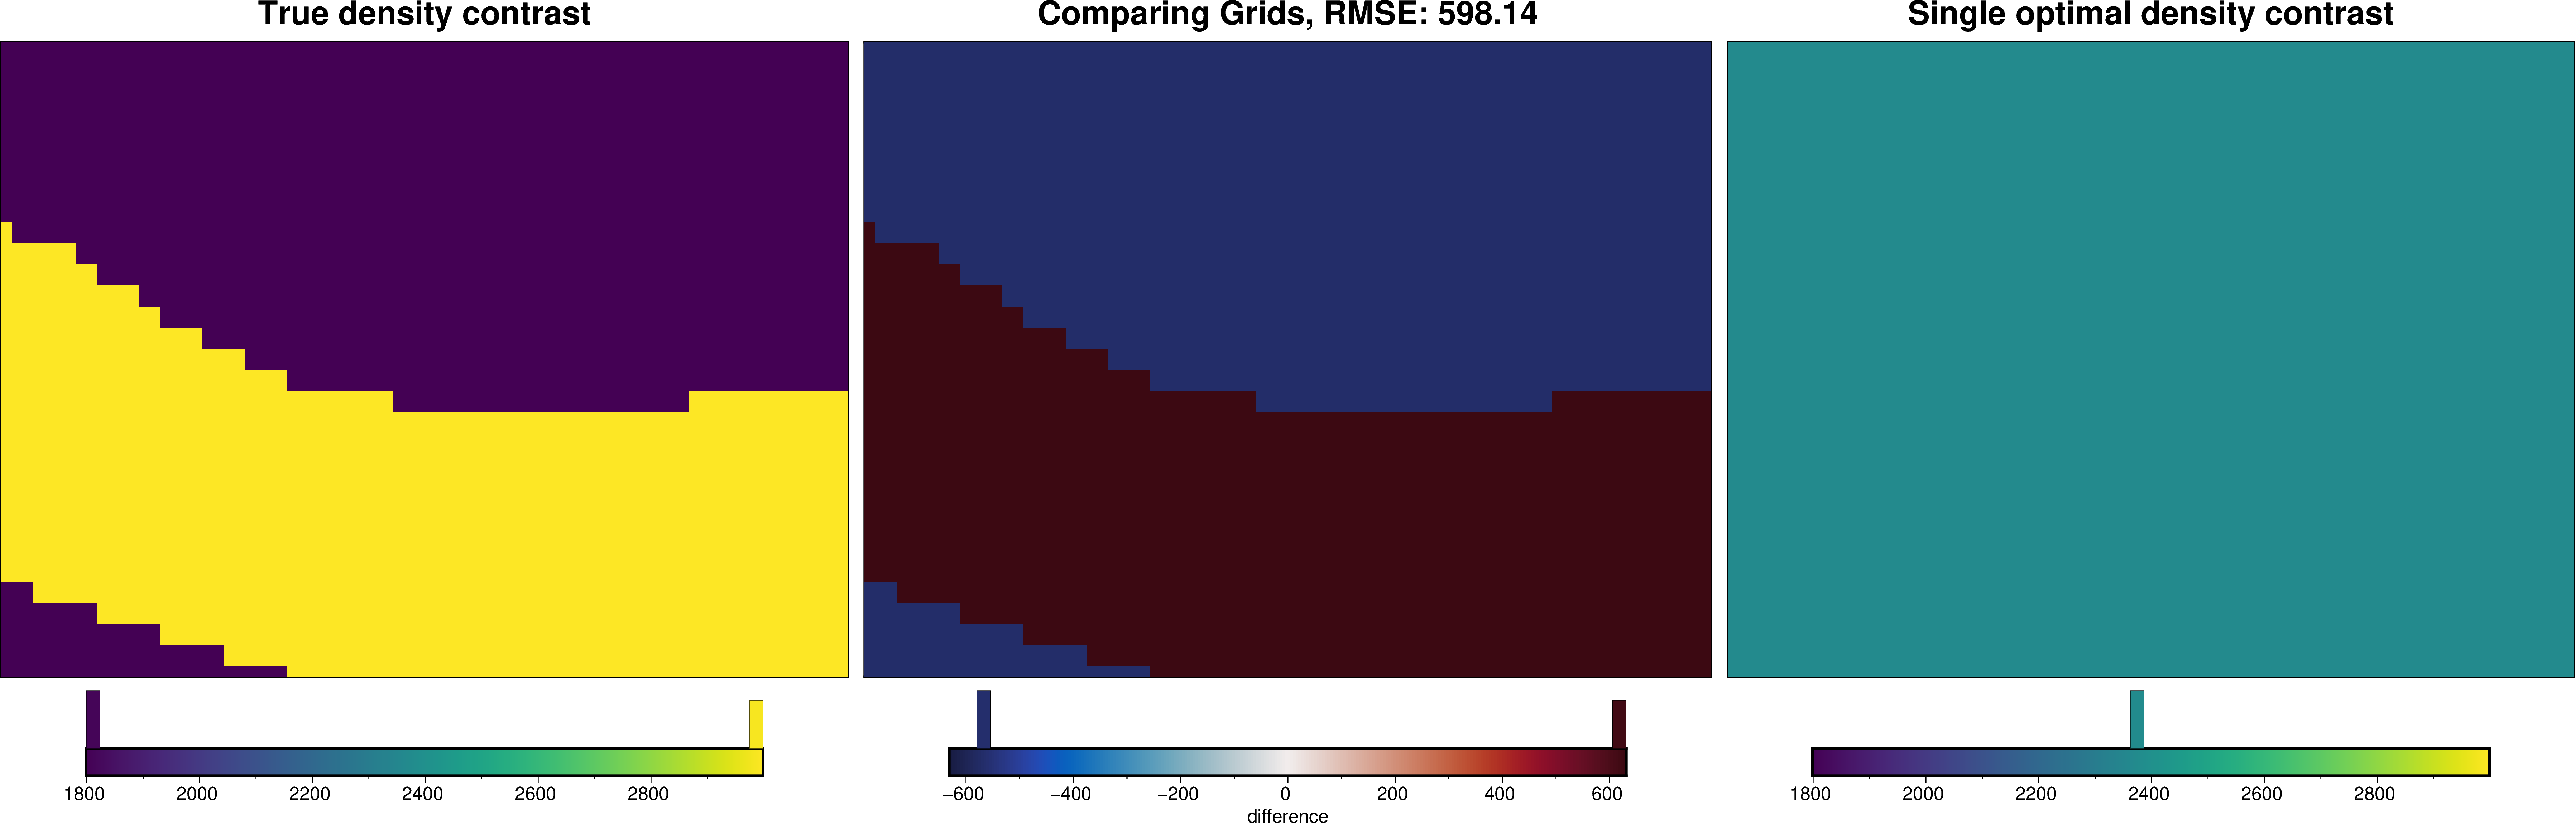

In [8]:
_ = ptk.grid_compare(
    true_density_contrast,
    xr.full_like(true_density_contrast, inv.used_density_contrast),
    grid1_name="True density contrast",
    grid2_name="Single optimal density contrast",
    robust=True,
    hist=True,
    inset=False,
    verbose="q",
    cmap="viridis",
)

/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:1820: FutureWarning: The 'barwidth' parameter has been deprecated since v0.18.0 and will be removed in v0.20.0. Please use 'bar_width' instead.
  self.histogram(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13

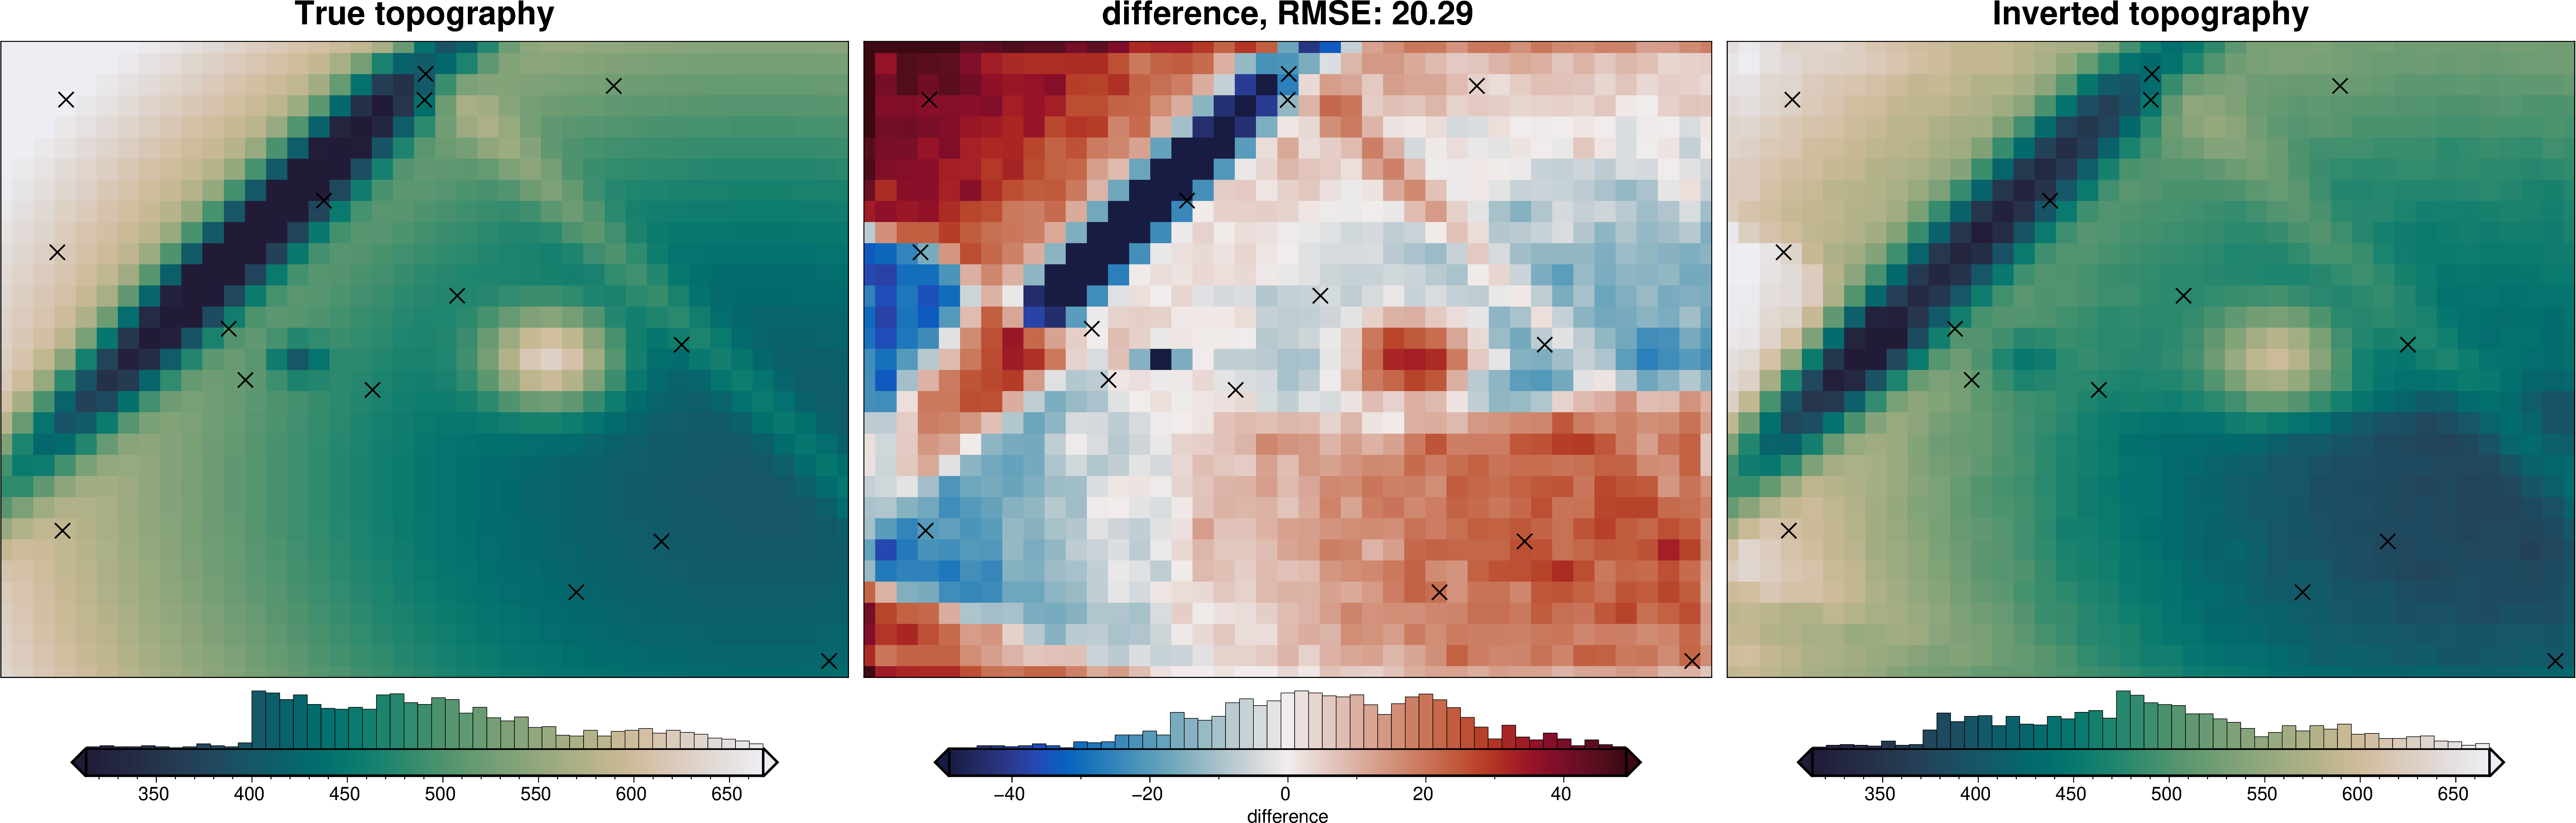

In [9]:
_ = ptk.grid_compare(
    true_topography,
    inv.model.topography,
    grid1_name="True topography",
    grid2_name="Inverted topography",
    robust=True,
    hist=True,
    inset=False,
    verbose="q",
    title="difference",
    reverse_cpt=True,
    cmap="rain",
    points=constraint_points,
    points_style="x.5c",
)

### Windowed density contrast optimization

Now we run the windowed optimization. Here we choose windows of 20 km width, overlapping by 50%, which for this region gives 6 windows. Around each window we include a 5 km buffer of gravity data to reduce edge effects, although constraint points within the buffer are not used for scoring. Windows containing fewer than `min_constraints` constraint points are skipped.

Within each window, a standard optimization (`optimize_inversion_zref_density_contrast`) is run with `n_trials` trials. The per-window optimal values are then interpolated into a grid with a spline (`merge_method="spline"`), clipped to the range of the window values, and a final inversion is run with the merged spatially variable density contrast grid.

In [10]:
inv.optimize_inversion_zref_density_contrast_windowed(
    n_trials=8,
    constraints_df=constraint_points,
    window_width=20000,
    window_overlap=0.5,
    window_buffer=5000,
    min_constraints=2,
    density_contrast_limits=(1500, 3200),
    regional_grav_kwargs={"method": "constant", "constant": 0},
    starting_topography_kwargs={"method": "flat"},
    fname="../tmp/windowed_density_optimization",
    progressbar=True,
)

Optimization windows:   0%|          | 0/6 [00:00<?, ?it/s]

Inversion terminated due to max_iterations limit. Consider increasing this limit.
'forward_gravity' already a variable of `grav_ds`, but is being overwritten since calculate_starting_gravity is True
'reg' already a column of `grav_df`, but is being overwritten since calculate_regional_misfit is True
Inversion terminated due to max_iterations limit. Consider increasing this limit.
'forward_gravity' already a variable of `grav_ds`, but is being overwritten since calculate_starting_gravity is True
'reg' already a column of `grav_df`, but is being overwritten since calculate_regional_misfit is True
Inversion terminated due to max_iterations limit. Consider increasing this limit.
'forward_gravity' already a variable of `grav_ds`, but is being overwritten since calculate_starting_gravity is True
'reg' already a column of `grav_df`, but is being overwritten since calculate_regional_misfit is True
Inversion terminated due to max_iterations limit. Consider increasing this limit.
'forward_gravit

The per-window results are stored in the `windowed_optimization_df` attribute, with each row giving the window's region, center coordinates, optimal parameter values, score, and the number of constraint points used for scoring.

In [11]:
inv.windowed_optimization_df

,window,easting,northing,region,zref,density_contrast,score,n_constraints
0,0,10000.0,10000.0,"(0.0, 20000.0, 0.0, 20000.0)",None,2853,3.252792,4
1,1,20000.0,10000.0,"(10000.0, 30000.0, 0.0, 20000.0)",None,2917,4.992456,5
2,2,30000.0,10000.0,"(20000.0, 40000.0, 0.0, 20000.0)",None,2988,7.743151,5
3,3,10000.0,20000.0,"(0.0, 20000.0, 10000.0, 30000.0)",None,2131,18.761116,7
4,4,20000.0,20000.0,"(10000.0, 30000.0, 10000.0, 30000.0)",None,1844,4.601566,8
5,5,30000.0,20000.0,"(20000.0, 40000.0, 10000.0, 30000.0)",None,1814,1.905367,4


The merged density contrast grid is used in the final inversion and stored as the `density_contrast` attribute of the model. Comparing it to the true density distribution shows the windowed scheme recovers the regional trend from low densities in the north to high densities in the south.

/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:1820: FutureWarning: The 'barwidth' parameter has been deprecated since v0.18.0 and will be removed in v0.20.0. Please use 'bar_width' instead.
  self.histogram(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13

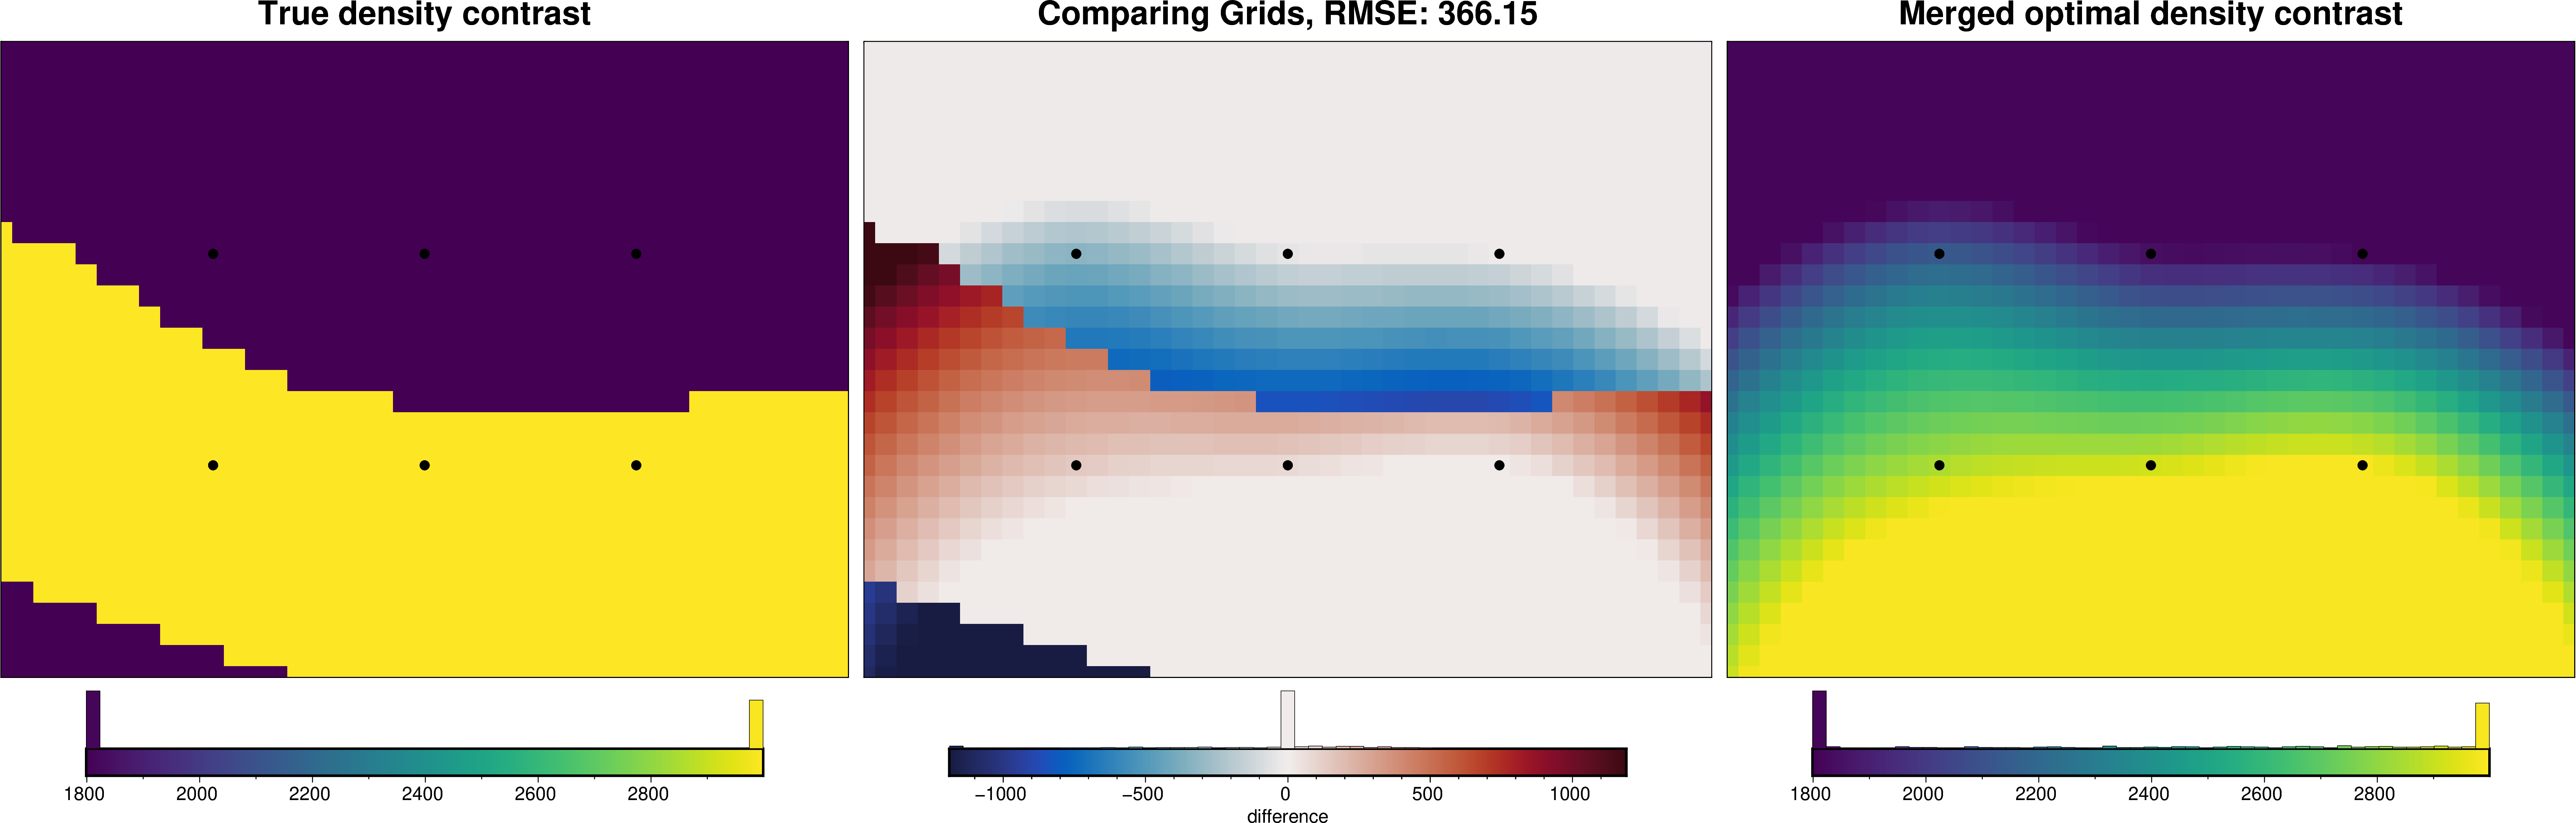

In [12]:
_ = ptk.grid_compare(
    true_density_contrast,
    inv.model.density_contrast,
    grid1_name="True density contrast",
    grid2_name="Merged optimal density contrast",
    robust=True,
    hist=True,
    inset=False,
    verbose="q",
    cmap="viridis",
    points=inv.windowed_optimization_df,
    points_style="c.2c",
)

/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:1820: FutureWarning: The 'barwidth' parameter has been deprecated since v0.18.0 and will be removed in v0.20.0. Please use 'bar_width' instead.
  self.histogram(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13

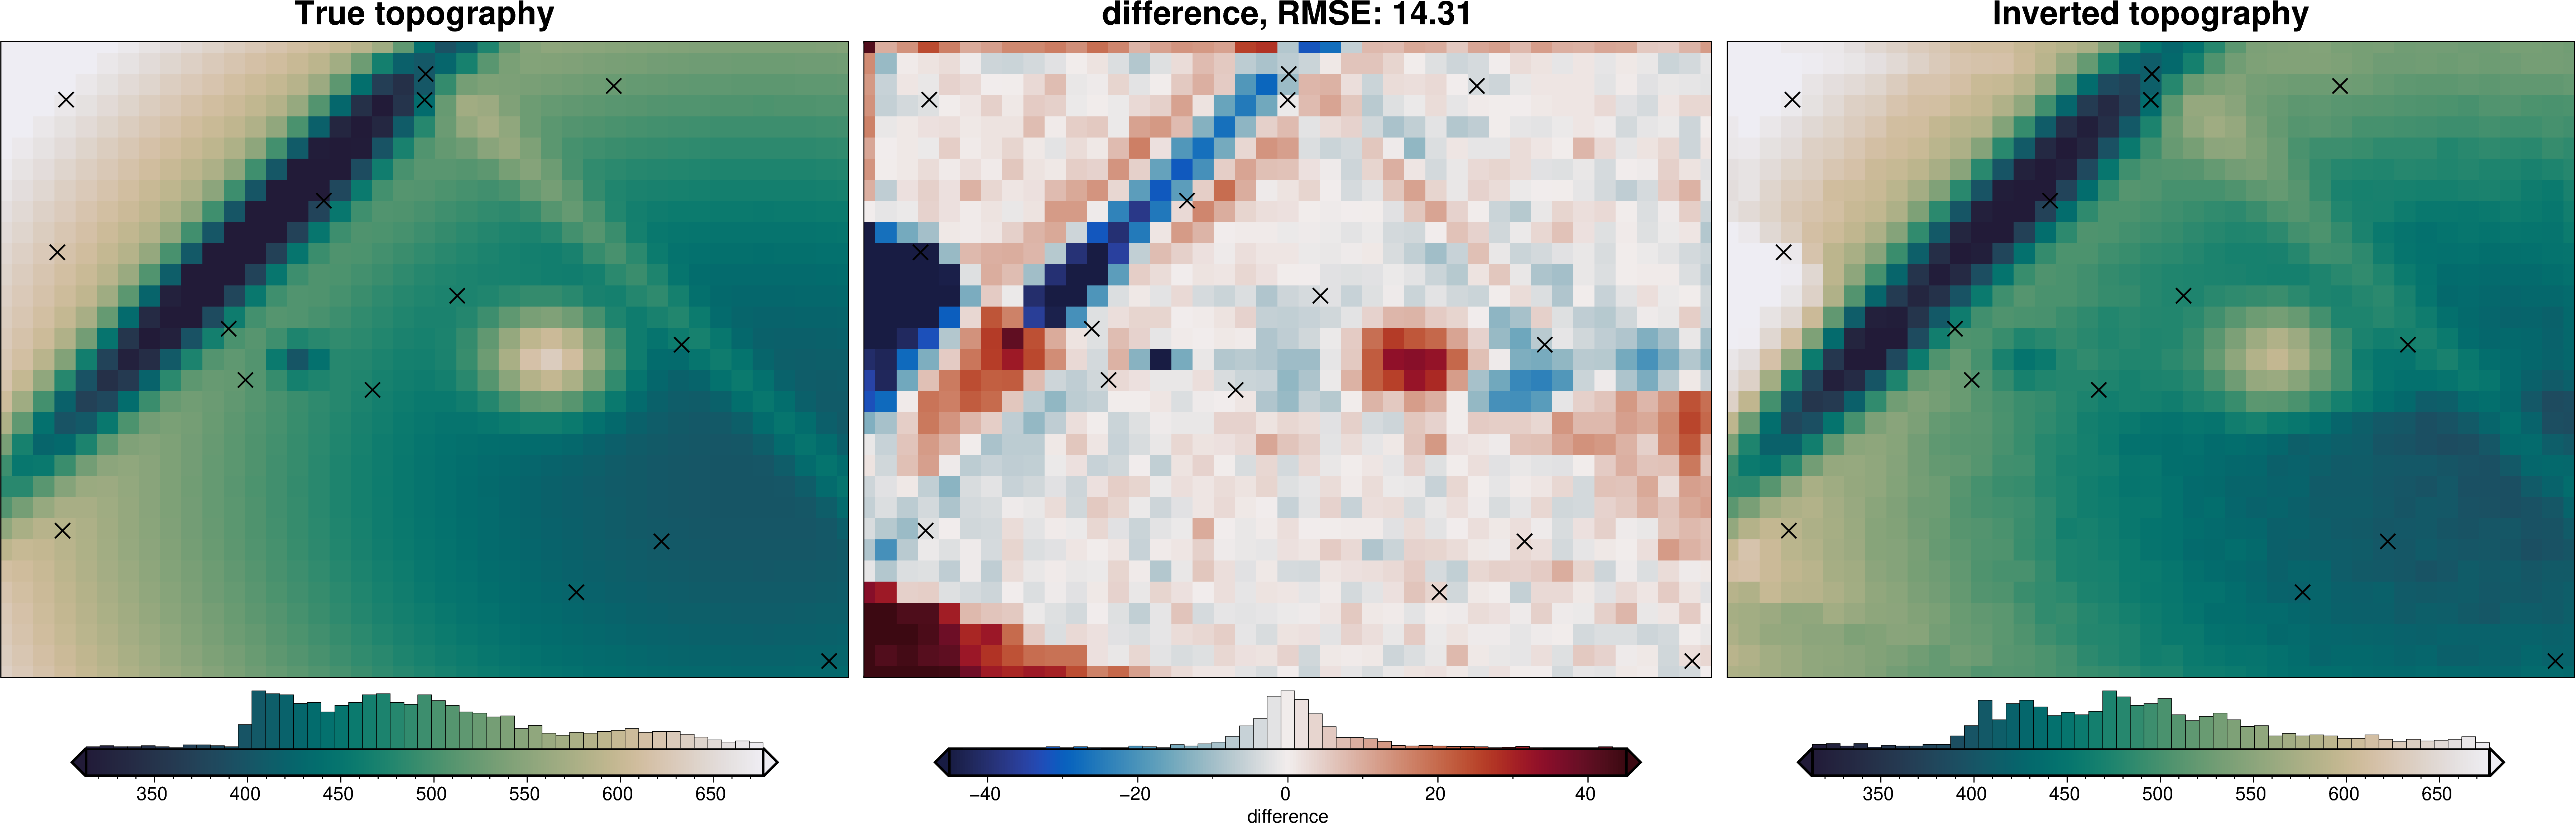

In [13]:
_ = ptk.grid_compare(
    true_topography,
    inv.model.topography,
    grid1_name="True topography",
    grid2_name="Inverted topography",
    robust=True,
    hist=True,
    inset=False,
    verbose="q",
    title="difference",
    reverse_cpt=True,
    cmap="rain",
    points=constraint_points,
    points_style="x.5c",
)

From the above figure, with our spatially variable estimated density contrast, we achieved an inversion with an RMSE of ~14 m. When we used a single density contrast value (non-spatially variable), the RMSE was ~20 m. 

## Reference level optimization

Next we look at the case where the density contrast is known, but the appropriate reference level varies spatially. To simulate this, we tilt the true topography with a linear ramp of 500 m across the region, and define a true reference level (used to calculate the observed gravity) as a 1st order trend fit to this tilted topography.

/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:1820: FutureWarning: The 'barwidth' parameter has been deprecated since v0.18.0 and will be removed in v0.20.0. Please use 'bar_width' instead.
  self.histogram(


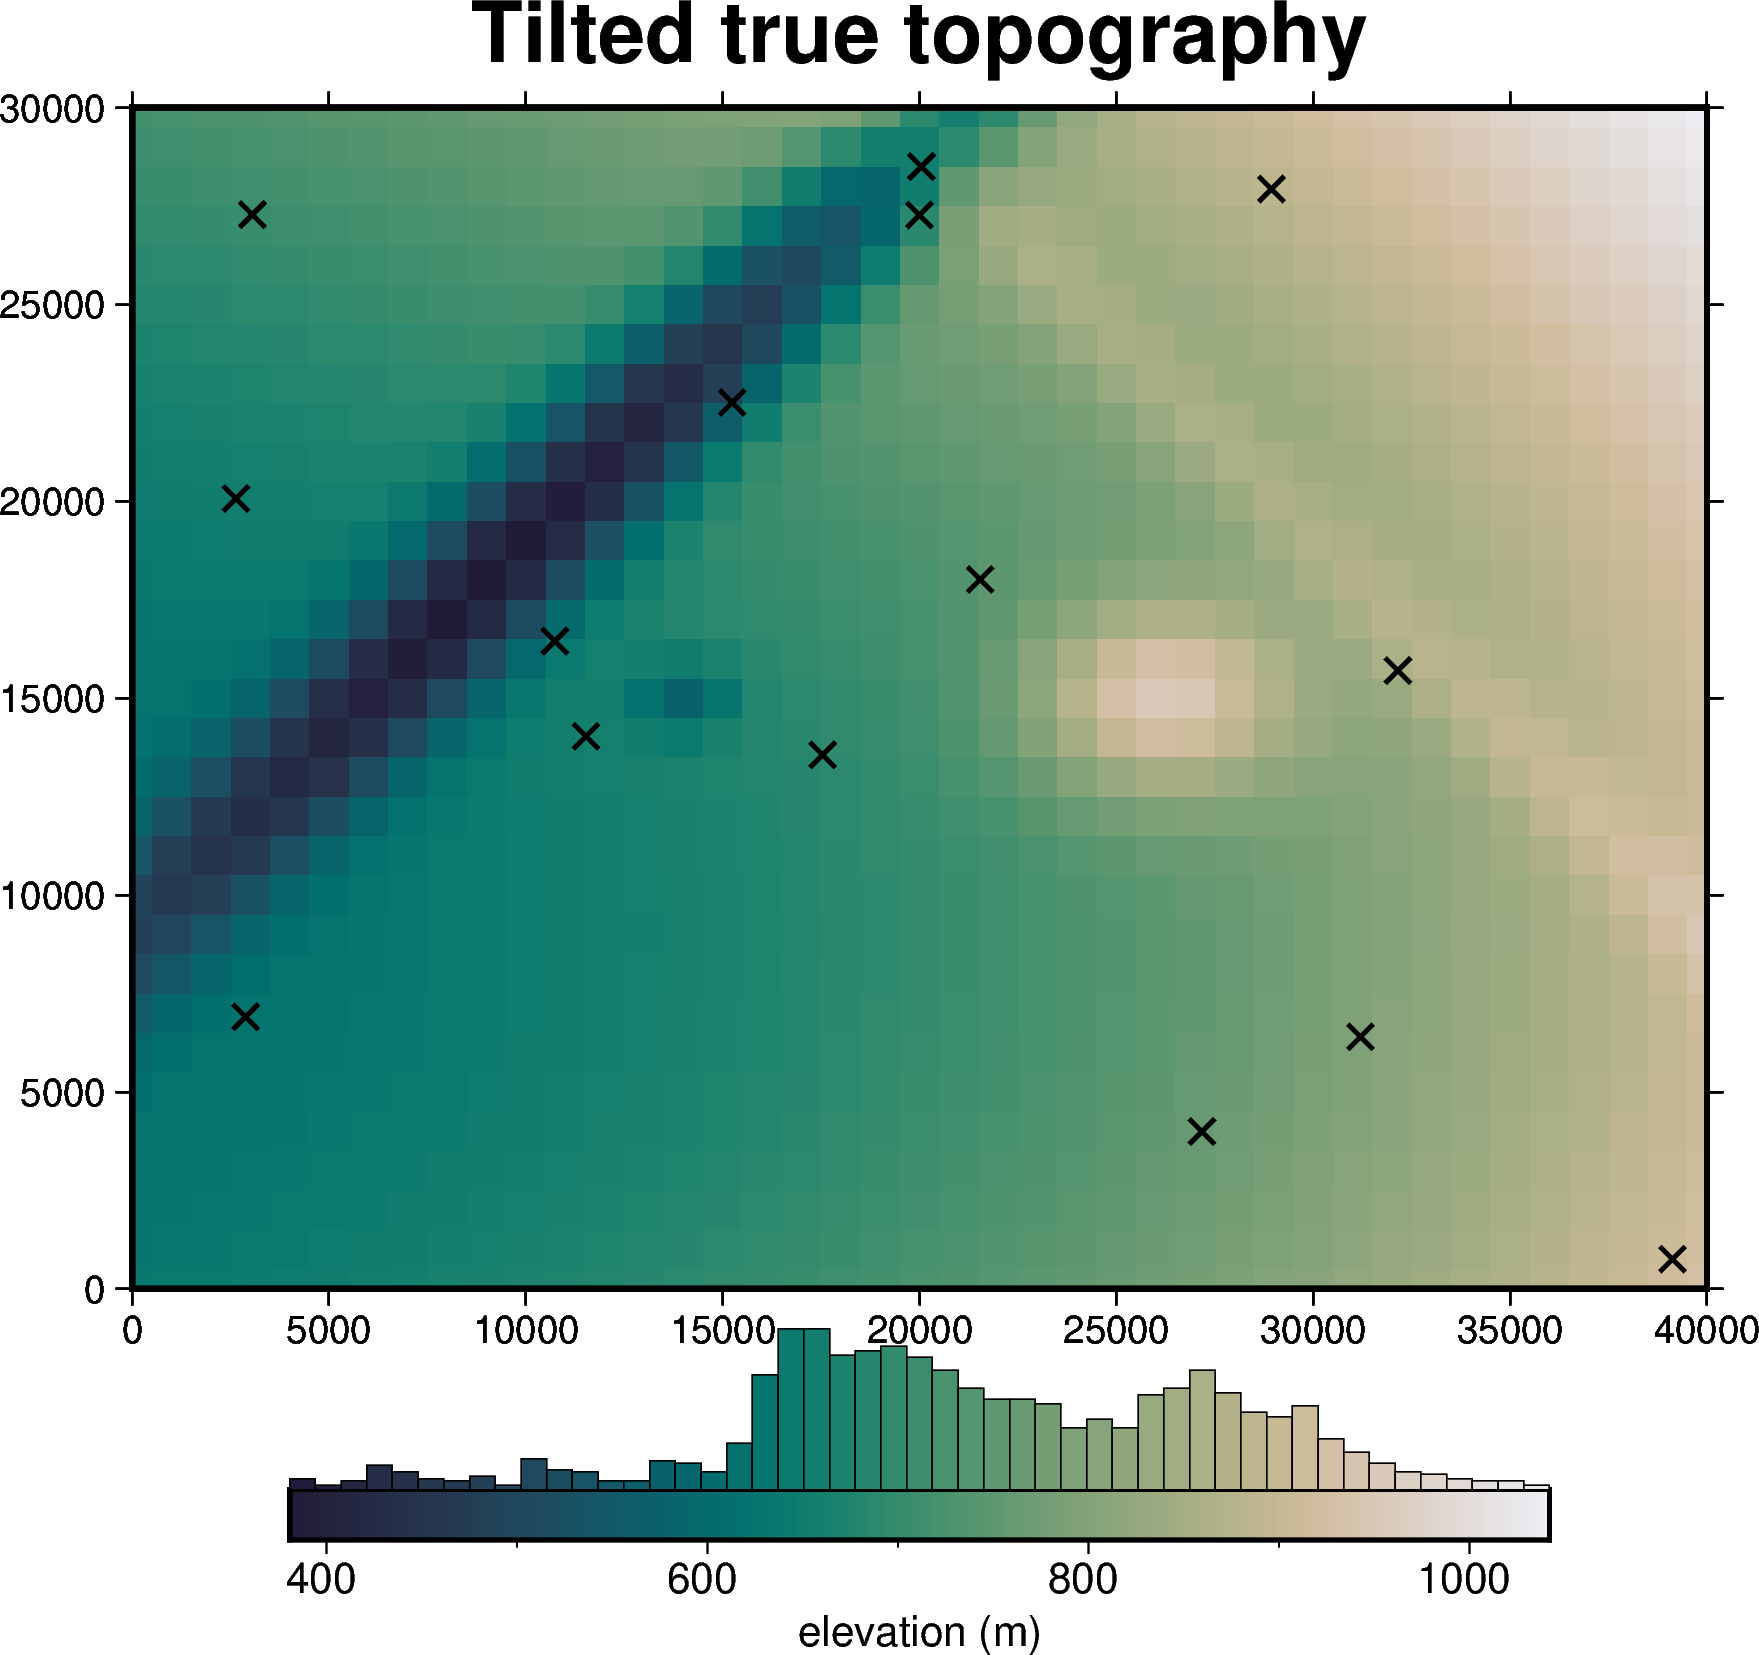

In [14]:
# tilt the true topography with a west-east ramp of 500 m
ramp = 500 * (
    (true_topography.easting - region[0]) / (region[1] - region[0])
).broadcast_like(true_topography)
tilted_topography = true_topography + ramp

# re-sample the constraint points on the tilted topography
tilted_constraints = constraint_points.drop(columns="upward")
tilted_constraints = invert4geom.sample_grids(
    tilted_constraints,
    tilted_topography,
    sampled_name="upward",
)

fig = ptk.plot_grid(
    tilted_topography,
    fig_height=10,
    title="Tilted true topography",
    cmap="rain",
    reverse_cpt=True,
    hist=True,
    cbar_label="elevation (m)",
    points=tilted_constraints,
    points_style="x.3c",
    frame=["nSWe", "xaf10000", "yaf10000"],
)
fig.show()

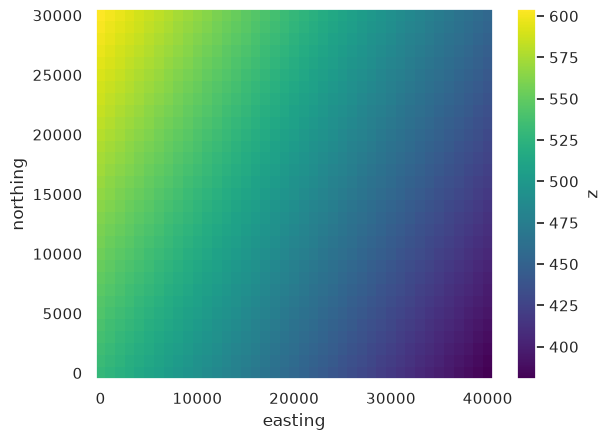

In [15]:
# make the true zref a 1st order trend fit the the true topography

df = vd.grid_to_table(true_topography)

vdtrend = vd.Trend(degree=1).fit(
    (df.easting, df.northing),
    df.upward,
)

true_zref = vdtrend.grid(
    coordinates=(tilted_topography.easting, tilted_topography.northing),
    data_names=["z"],
    dims=("northing", "easting"),
).z

true_zref.plot()

In [16]:
# the true density contrast is a constant 2669 kg/m3 in this scenario
data = make_observed_gravity(tilted_topography, 2669, true_zref)

# create the starting model with the known density and a first guess for zref,
starting_topography = invert4geom.create_topography(
    method="flat",
    upward=true_zref.values.mean(),
    region=region,
    spacing=spacing,
)
starting_model = invert4geom.create_model(
    zref=true_zref,
    density_contrast=2669,
    topography=starting_topography,
)
data.inv.forward_gravity(starting_model)
data.inv.regional_separation(method="constant", constant=0)

inv = invert4geom.Inversion(
    data,
    starting_model,
    solver_damping=0.1,
    max_iterations=30,
    l2_norm_tolerance=0.45,  # gravity error is 0.2 mGal
    delta_l2_norm_tolerance=1.005,
)

### Normal reference level optimization

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

'forward_gravity' already a variable of `grav_ds`, but is being overwritten since calculate_starting_gravity is True
'reg' already a column of `grav_df`, but is being overwritten since calculate_regional_misfit is True


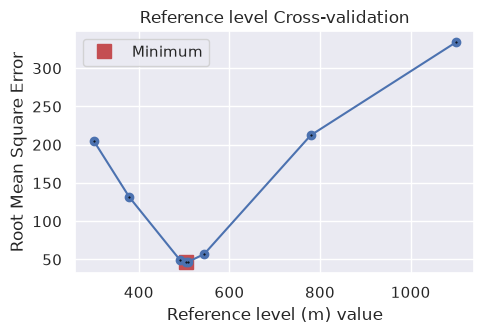

In [17]:
zref_optimization_obj = inv.optimize_inversion_zref_density_contrast(
    n_trials=8,
    constraints_df=tilted_constraints,
    zref_limits=(300, 1100),
    regional_grav_kwargs={"method": "constant", "constant": 0},
    starting_topography_kwargs={"method": "flat"},
    fname="../tmp/single_zref_optimization",
    progressbar=True,
)

/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:1820: FutureWarning: The 'barwidth' parameter has been deprecated since v0.18.0 and will be removed in v0.20.0. Please use 'bar_width' instead.
  self.histogram(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13

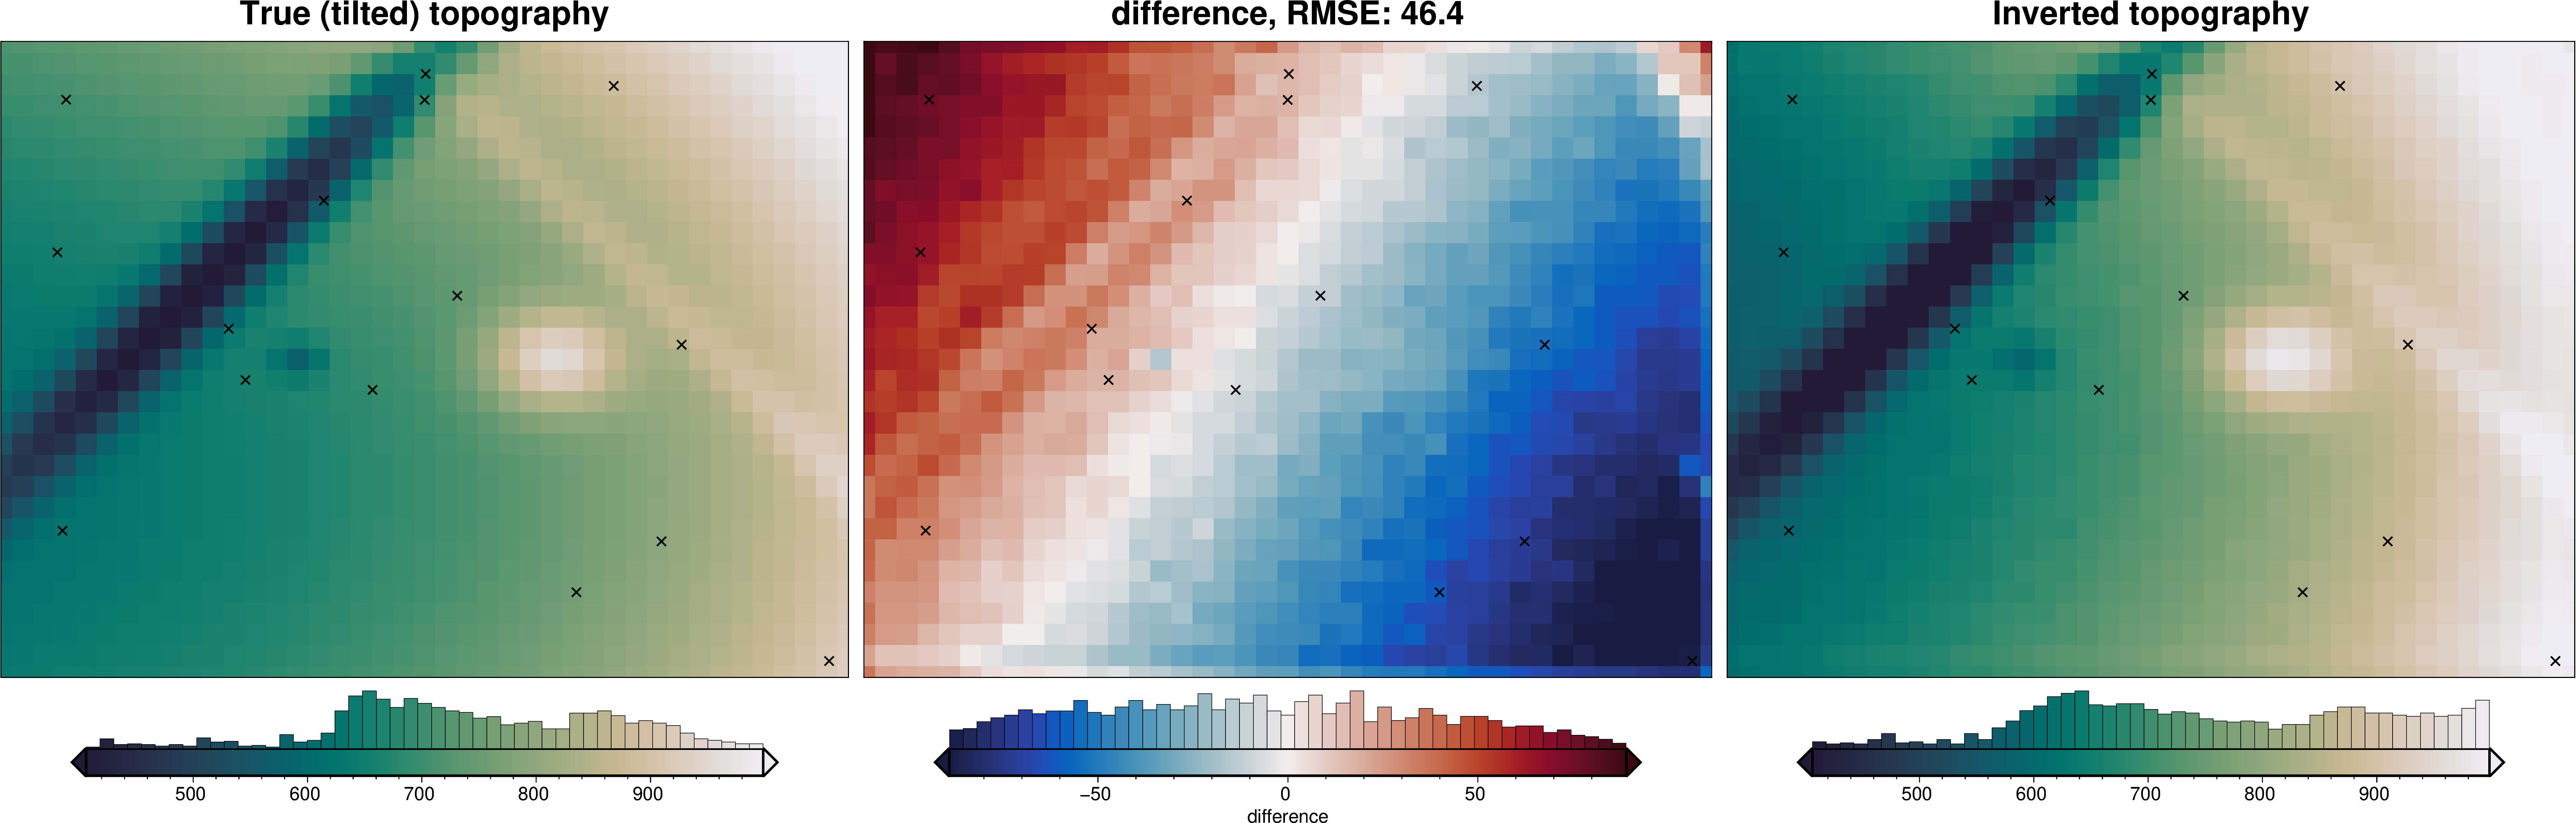

In [18]:
_ = ptk.grid_compare(
    tilted_topography,
    inv.model.topography,
    grid1_name="True (tilted) topography",
    grid2_name="Inverted topography",
    robust=True,
    hist=True,
    inset=False,
    verbose="q",
    title="difference",
    reverse_cpt=True,
    cmap="rain",
    points=tilted_constraints,
    points_style="x.3c",
)

###  Windowed zref optimization

In [19]:
inv.optimize_inversion_zref_density_contrast_windowed(
    n_trials=8,
    constraints_df=tilted_constraints,
    window_width=10000,
    window_overlap=0.5,
    window_buffer=2000,
    min_constraints=2,
    zref_limits=(300, 1100),
    regional_grav_kwargs={"method": "constant", "constant": 0},
    starting_topography_kwargs={"method": "flat"},
    fname="../tmp/windowed_zref_optimization",
    progressbar=True,
)

Optimization windows:   0%|          | 0/35 [00:00<?, ?it/s]

skipping window 0; 1 constraint points inside window but 2 required
skipping window 1; 0 constraint points inside window but 2 required
skipping window 2; 0 constraint points inside window but 2 required
skipping window 3; 0 constraint points inside window but 2 required
skipping window 4; 1 constraint points inside window but 2 required
'forward_gravity' already a variable of `grav_ds`, but is being overwritten since calculate_starting_gravity is True
'reg' already a column of `grav_df`, but is being overwritten since calculate_regional_misfit is True
'forward_gravity' already a variable of `grav_ds`, but is being overwritten since calculate_starting_gravity is True
'reg' already a column of `grav_df`, but is being overwritten since calculate_regional_misfit is True
skipping window 7; 1 constraint points inside window but 2 required
skipping window 8; 1 constraint points inside window but 2 required
Inversion terminated due to max_iterations limit. Consider increasing this limit.
'for

In [20]:
inv.windowed_optimization_df

,window,easting,northing,region,zref,density_contrast,score,n_constraints
0,5,30000.0,5000.0,"(25000.0, 35000.0, 0.0, 10000.0)",433.916769,None,6.546223,2
1,6,35000.0,5000.0,"(30000.0, 40000.0, 0.0, 10000.0)",409.190240,None,15.433747,2
2,9,15000.0,10000.0,"(10000.0, 20000.0, 5000.0, 15000.0)",505.892247,None,14.934851,2
3,15,10000.0,15000.0,"(5000.0, 15000.0, 10000.0, 20000.0)",520.731824,None,2.907364,2
4,16,15000.0,15000.0,"(10000.0, 20000.0, 10000.0, 20000.0)",510.488718,None,14.520618,3
5,17,20000.0,15000.0,"(15000.0, 25000.0, 10000.0, 20000.0)",493.105210,None,4.590245,2
6,23,15000.0,20000.0,"(10000.0, 20000.0, 15000.0, 25000.0)",527.077170,None,2.991530,2
7,24,20000.0,20000.0,"(15000.0, 25000.0, 15000.0, 25000.0)",505.845613,None,19.063215,2
8,28,5000.0,25000.0,"(0.0, 10000.0, 20000.0, 30000.0)",573.132797,None,5.688308,2
9,30,15000.0,25000.0,"(10000.0, 20000.0, 20000.0, 30000.0)",520.299866,None,6.478344,2


/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:1820: FutureWarning: The 'barwidth' parameter has been deprecated since v0.18.0 and will be removed in v0.20.0. Please use 'bar_width' instead.
  self.histogram(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13

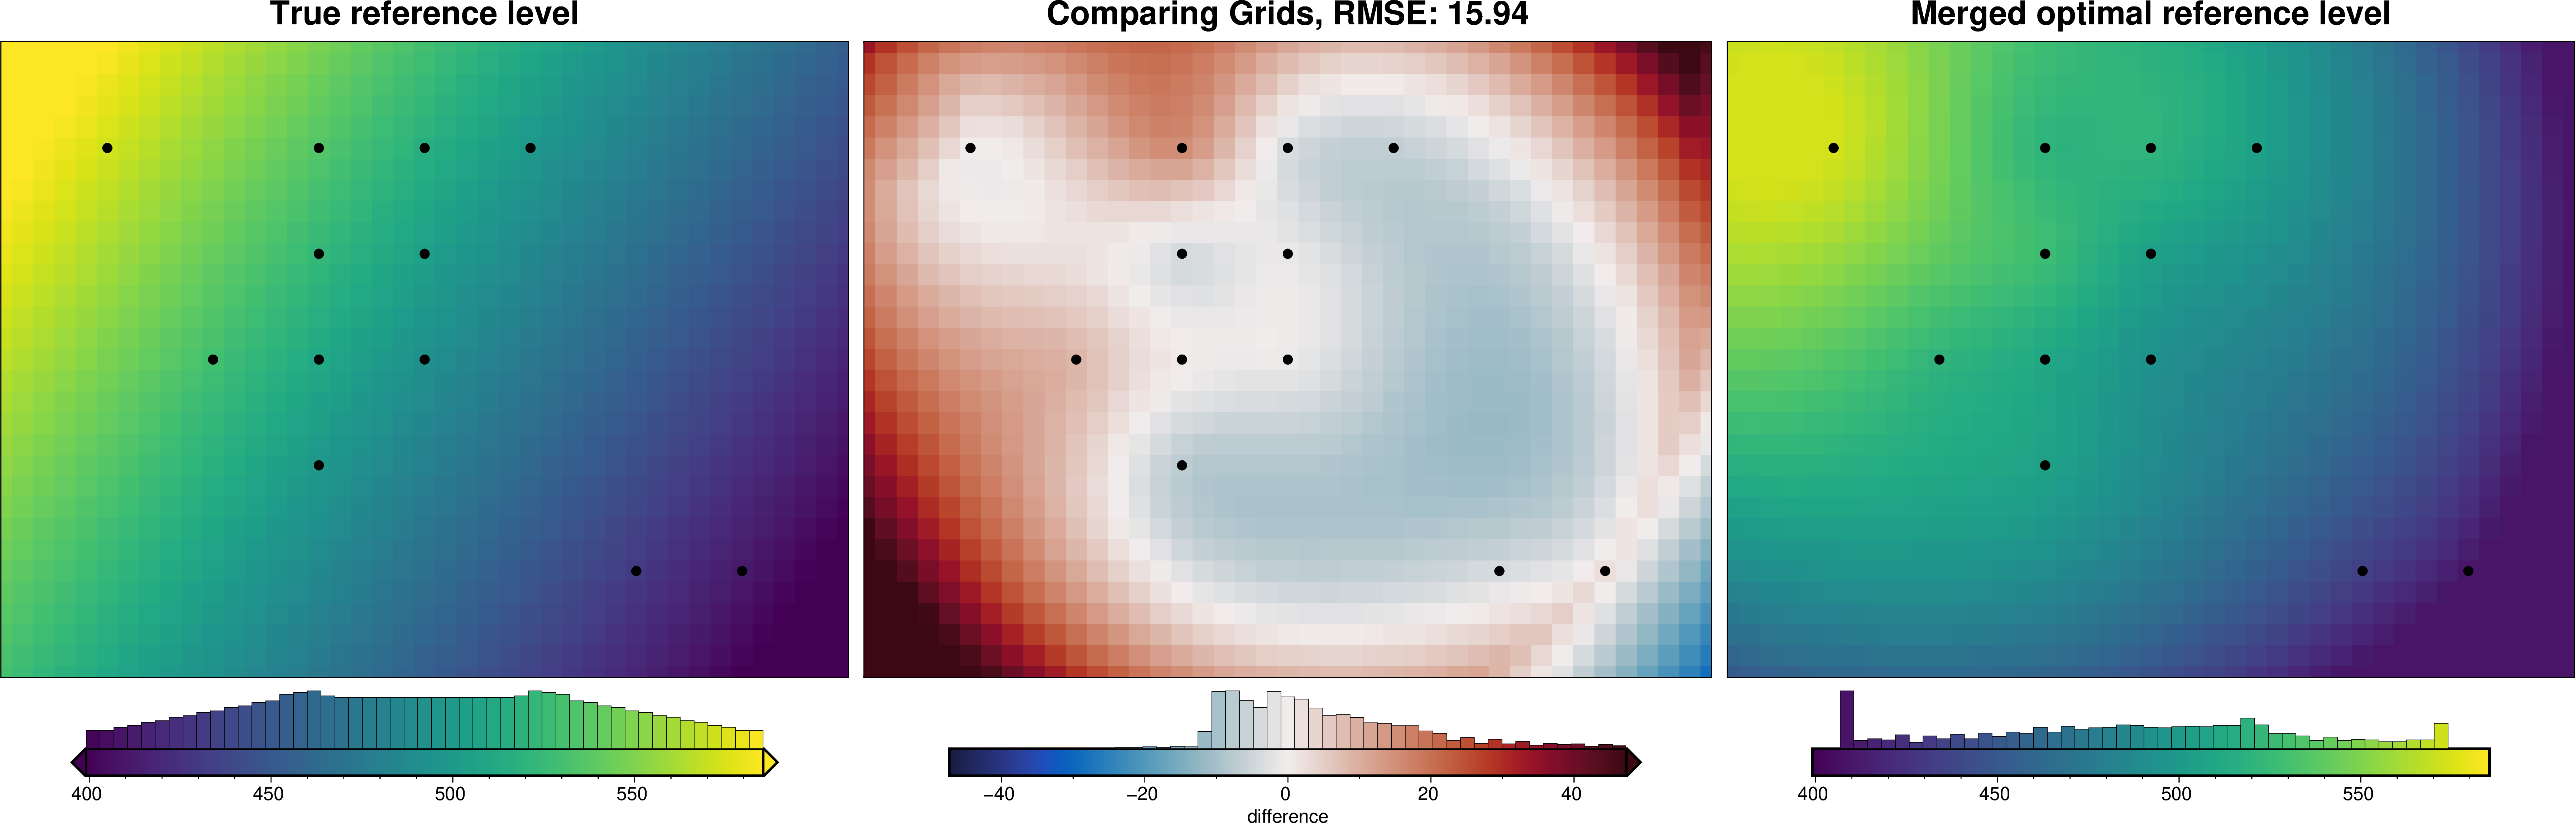

In [21]:
_ = ptk.grid_compare(
    true_zref,
    inv.model.zref,
    grid1_name="True reference level",
    grid2_name="Merged optimal reference level",
    robust=True,
    hist=True,
    inset=False,
    verbose="q",
    cmap="viridis",
    points=inv.windowed_optimization_df,
    points_style="c.2c",
)

/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:1820: FutureWarning: The 'barwidth' parameter has been deprecated since v0.18.0 and will be removed in v0.20.0. Please use 'bar_width' instead.
  self.histogram(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13/site-packages/polartoolkit/maps.py:138: UserWarning: EPSG:3857 (Web Mercator) is not recommended, especially for high latitudes as it can cause significant distortion. Consider using a different projection.
  self.proj, self.proj_latlon, self.width, self.height = utils.set_proj(
/home/mdtanker/invert4geom/.pixi/envs/default/lib/python3.13

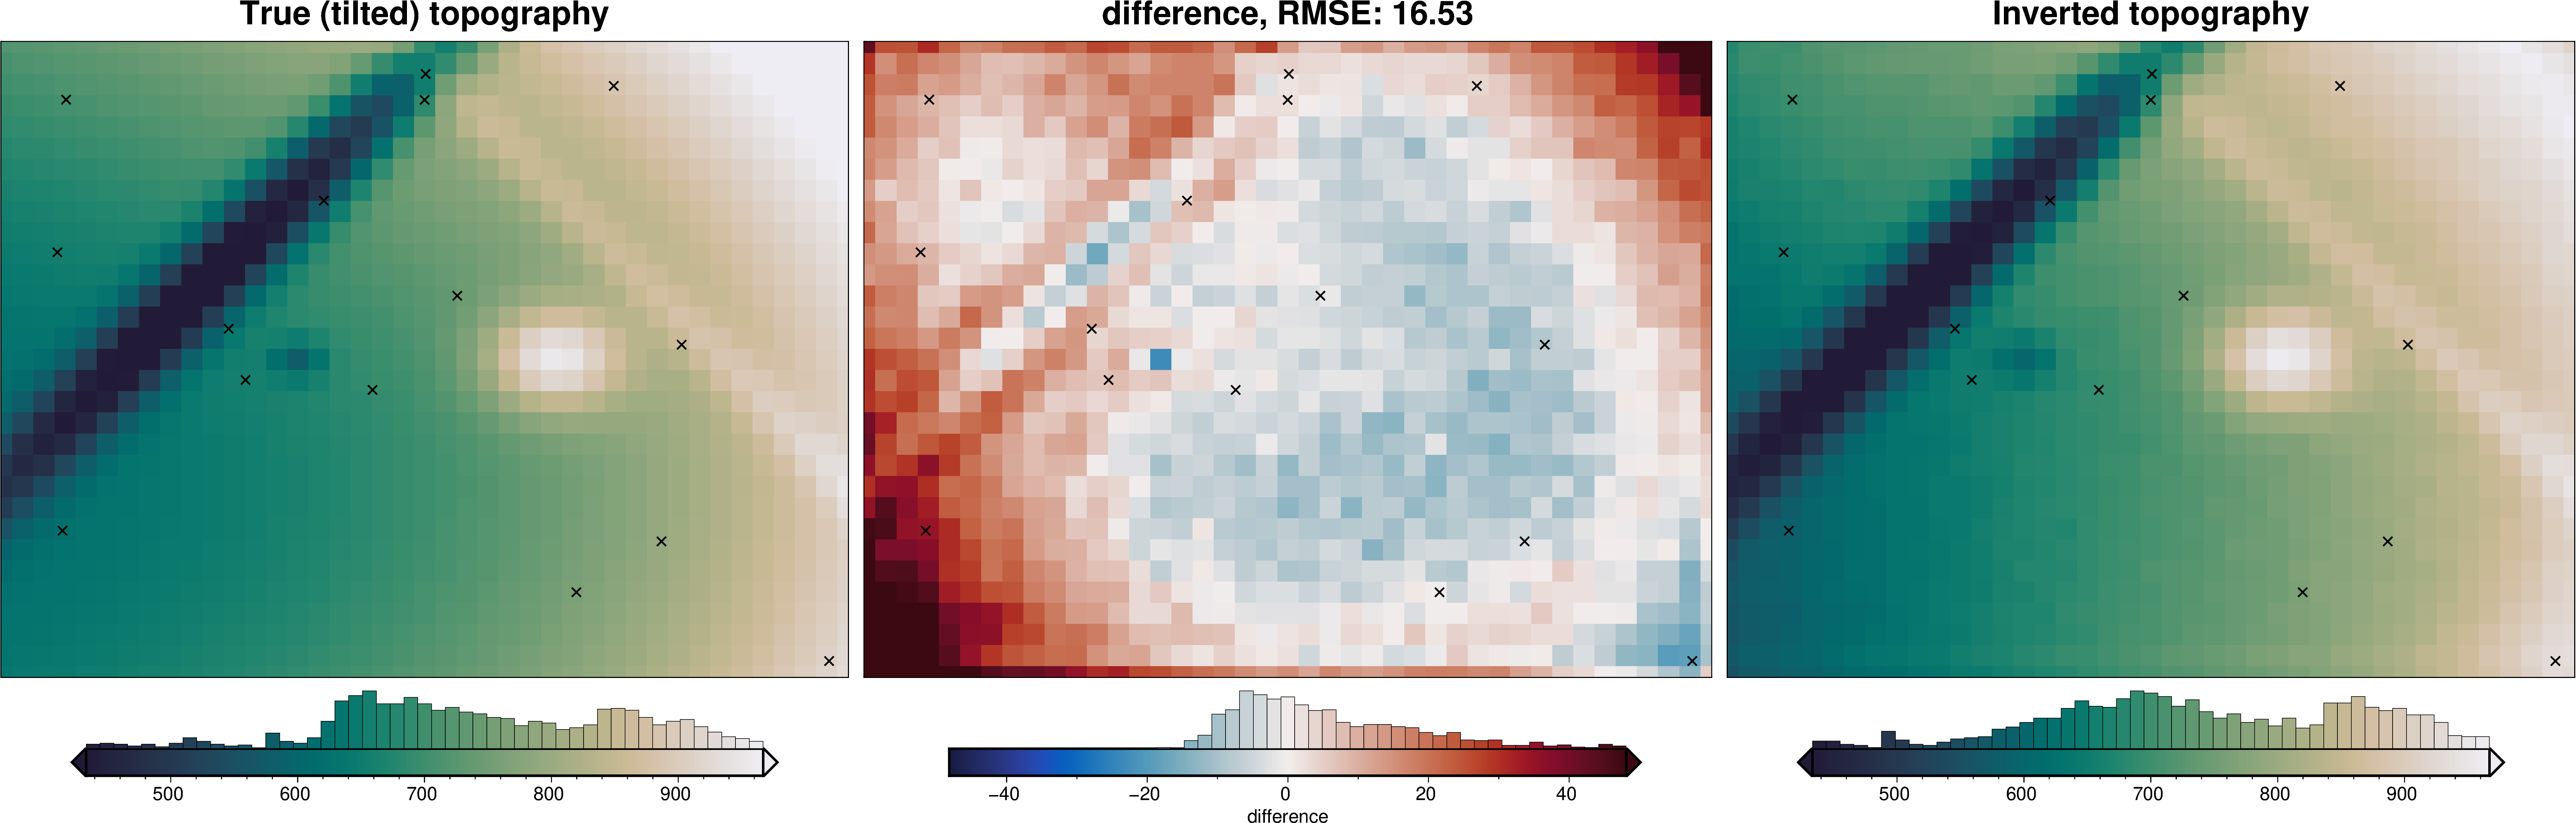

In [22]:
_ = ptk.grid_compare(
    tilted_topography,
    inv.model.topography,
    grid1_name="True (tilted) topography",
    grid2_name="Inverted topography",
    robust=True,
    hist=True,
    inset=False,
    verbose="q",
    title="difference",
    reverse_cpt=True,
    cmap="rain",
    points=tilted_constraints,
    points_style="x.3c",
)

From the above figure, with our spatially variable estimated reference level, we achieved an inversion with an RMSE of ~17 m. When we used a single reference level (non-spatially variable), the RMSE was ~46 m. 

## Practical considerations
Some tips for using the windowed scheme on real data:

- **Window width**: windows need to be small enough to capture the spatial variability you expect, but large enough that each window contains enough gravity data and constraint points for a meaningful optimization. The number of constraints is usually the limiting factor.
- **Overlap**: overlapping windows (e.g. `window_overlap=0.5`) give more window centers and smoother merged grids, at the cost of more optimizations.
- **Buffer**: `window_buffer` includes extra gravity data around each window to reduce edge effects in the per-window inversions, without using the extra constraint points for scoring. It must be a multiple of the grid spacing.
- **Skipped windows**: windows with fewer than `min_constraints` constraint points, or where the optimization fails, are skipped with a logged warning. Check `windowed_optimization_df` to see which windows contributed.
- **Merging**: `merge_method="spline"` (optionally with `merge_damping`) gives smooth grids, while `merge_method="nearest"` gives a piecewise-constant mosaic. Merged values are always clipped to the range of the per-window optimal values.
- **Cost**: the total number of inversions is roughly `number of windows x (n_trials + 1)`, plus the final full-region inversion, so start with few windows and trials.